# NYISO Solar Forecasting: Physics-Informed Feature Engineering for Residual Learning

## Imports and Configuration

In [35]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [36]:
repo_root = Path.home() / "Documents" / "Coding" / "ML_NYISOSolarForecast"

data_root = repo_root / "data"
processed_dir = data_root / "processed"

merged_out = processed_dir / "03_merged_data.csv"

df = pd.read_csv(merged_out, low_memory=False)

## Standardize Columns 

In [37]:
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("-", "_", regex=False)
)

df["time_stamp"] = pd.to_datetime(df["time_stamp"], utc=True, errors="coerce")

if "time" in df.columns:
    df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce")
    same_time_mask = (df["time"] == df["time_stamp"]) | (
        df["time"].isna() & df["time_stamp"].isna()
    )
    if bool(same_time_mask.all()):
        df = df.drop(columns=["time"])

numeric_cols = [
    "actual_mw",
    "forecast_mw",
    "capacity_mw",
    "temperature_2m",
    "surface_pressure",
    "cloud_cover",
    "windspeed_10m",
    "shortwave_radiation",
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["zone_name"] = df["zone_name"].astype(str).str.strip().str.upper()

## Time and Error Metric Features

In [38]:
df["time_local"] = df["time_stamp"].dt.tz_convert("America/New_York")


df["year_from_ts"] = df["time_local"].dt.year
df["month_local"] = df["time_local"].dt.month
df["dayofweek_local"] = df["time_local"].dt.dayofweek
df["hour_local"] = df["time_local"].dt.hour

df["is_weekend"] = df["dayofweek_local"].isin([5, 6]).astype(int)
df["is_daylight_proxy"] = (df["shortwave_radiation"] > 0).astype(int)

In [39]:
df["forecast_error_mw"] = df["actual_mw"] - df["forecast_mw"]
df["absolute_error_mw"] = (df["actual_mw"] - df["forecast_mw"]).abs()
df["smape"] = np.where(
    (df["actual_mw"].abs() + df["forecast_mw"].abs()) > 0,
    200 * df["absolute_error_mw"] / (df["actual_mw"].abs() + df["forecast_mw"].abs()),
    np.nan
)

## SYSTEM-Only Modeling Table

In [40]:
df_system = (
    df[df["zone_name"] == "SYSTEM"]
    .copy()
    .sort_values("time_stamp")
    .reset_index(drop=True)
)

print("System Shape:", df_system.shape)
print("System Time Range:", df_system["time_stamp"].min(), "to", df_system["time_stamp"].max())
print("System Columns:", df_system.columns.tolist())

System Shape: (42455, 21)
System Time Range: 2020-11-17 05:00:00+00:00 to 2025-09-21 03:00:00+00:00
System Columns: ['time_stamp', 'zone_name', 'actual_mw', 'forecast_mw', 'capacity_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'year', 'time_local', 'year_from_ts', 'month_local', 'dayofweek_local', 'hour_local', 'is_weekend', 'is_daylight_proxy', 'forecast_error_mw', 'absolute_error_mw', 'smape']


### Encoding Cyclic Time 
solar gen is periodic with 24 hours and 365 days, sin(theta) = sin((2*pi*t)/T)

In [41]:
df_system["dayofyear_local"] = df_system["time_local"].dt.dayofyear
df_system["weekofyear_local"] = df_system["time_local"].dt.isocalendar().week.astype(int)

df_system["hour_sin"] = np.sin(2 * np.pi * df_system["hour_local"] / 24)
df_system["hour_cos"] = np.cos(2 * np.pi * df_system["hour_local"] / 24)

df_system["month_sin"] = np.sin(2 * np.pi * df_system["month_local"] / 12)
df_system["month_cos"] = np.cos(2 * np.pi * df_system["month_local"] / 12)

df_system["dayofyear_sin"] = np.sin(2 * np.pi * df_system["dayofyear_local"] / 365.25)
df_system["dayofyear_cos"] = np.cos(2 * np.pi * df_system["dayofyear_local"] / 365.25)

df_system["dayofweek_sin"] = np.sin(2 * np.pi * df_system["dayofweek_local"] / 7)
df_system["dayofweek_cos"] = np.cos(2 * np.pi * df_system["dayofweek_local"] / 7)

### Solar Regimes

In [42]:
df_system["is_morning_ramp"] = df_system["hour_local"].between(6, 9).astype(int)
df_system["is_midday"] = df_system["hour_local"].between(10, 14).astype(int)
df_system["is_evening_ramp"] = df_system["hour_local"].between(15, 18).astype(int)
df_system["is_night"] = (df_system["is_daylight_proxy"] == 0).astype(int)

### Understanding Capacity 
capacity ratio is forecast/installed cap

In [43]:
df_system["capacity_ffill"] = df_system["capacity_mw"].ffill().bfill()

df_system["forecast_capacity_ratio"] = np.where(
    df_system["capacity_ffill"] > 0,
    df_system["forecast_mw"] / df_system["capacity_ffill"],
    np.nan
)

if "capacity_mw" in df_system.columns:
    df_system["capacity_ffill_safe"] = df_system["capacity_mw"].ffill()
    df_system["capacity_missing_flag"] = df_system["capacity_mw"].isna().astype(int)

    df_system["forecast_capacity_ratio_safe"] = np.where(
        df_system["capacity_ffill_safe"].notna() & (df_system["capacity_ffill_safe"] > 0),
        df_system["forecast_mw"] / df_system["capacity_ffill_safe"],
        np.nan
    )

### Physics-Informed Features Interactions
PV depends on irradiance, temp, and how clouds move
P= f(G,T,C)

In [44]:
df_system["cloud_cover_frac"] = df_system["cloud_cover"] / 100.0

df_system["forecast_mw_log1p"] = np.log1p(df_system["forecast_mw"].clip(lower=0))
df_system["shortwave_radiation_log1p"] = np.log1p(df_system["shortwave_radiation"].clip(lower=0))

In [45]:
interaction_features = pd.DataFrame(index=df_system.index)

interaction_features["forecast_x_hour_sin"] = df_system["forecast_mw"] * df_system["hour_sin"]
interaction_features["forecast_x_hour_cos"] = df_system["forecast_mw"] * df_system["hour_cos"]

interaction_features["shortwave_x_cloud"] = (
    df_system["shortwave_radiation"] * df_system["cloud_cover_frac"]
)

interaction_features["shortwave_x_temp"] = (
    df_system["shortwave_radiation"] * df_system["temperature_2m"]
)

interaction_features["temp_x_wind"] = (
    df_system["temperature_2m"] * df_system["windspeed_10m"]
)

df_system = pd.concat([df_system, interaction_features], axis=1)

### Rolling Windows and Ramp Features

In [46]:
rolling_windows = [3, 6, 24]

rolling_features = {}

for w in rolling_windows:

    rolling_features[f"forecast_roll_mean_{w}"] = (
        df_system["forecast_mw"].shift(1).rolling(w, min_periods=1).mean()
    )

    rolling_features[f"shortwave_roll_mean_{w}"] = (
        df_system["shortwave_radiation"].shift(1).rolling(w, min_periods=1).mean()
    )

rolling_df = pd.DataFrame(rolling_features)

df_system = pd.concat([df_system, rolling_df], axis=1)

In [47]:
df_system["forecast_diff_1"] = df_system["forecast_mw"].diff(1)
df_system["shortwave_diff_1"] = df_system["shortwave_radiation"].diff(1)

df_system["forecast_ramp_abs"] = df_system["forecast_diff_1"].abs()
df_system["shortwave_ramp_abs"] = df_system["shortwave_diff_1"].abs()

## Missingness Summary

In [48]:
feature_missing_summary = (
    pd.DataFrame({
        "column": df_system.columns,
        "dtype": [str(df_system[c].dtype) for c in df_system.columns],
        "missing_count": [df_system[c].isna().sum() for c in df_system.columns],
    })
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df_system))
    .sort_values(["missing_count", "column"], ascending=[False, True])
)

feature_missing_summary.head(40)

,column,dtype,missing_count,missing_pct
36,forecast_capacity_ratio,float64,26504,62.428454
39,forecast_capacity_ratio_safe,float64,26504,62.428454
37,capacity_ffill_safe,float64,23903,56.301967
4,capacity_mw,float64,23903,56.301967
20,smape,float64,18910,44.541279
19,absolute_error_mw,float64,1000,2.355435
18,forecast_error_mw,float64,1000,2.355435
2,actual_mw,float64,712,1.677070
54,forecast_diff_1,float64,301,0.708986
56,forecast_ramp_abs,float64,301,0.708986


## Modeling Dataset
The target is the residual, the error. Also columns that could cause leakage needs to be dropped.

In [49]:
target = "forecast_error_mw"

drop_cols = [
    "actual_mw",
    "absolute_error_mw",
    "smape",
    "time_stamp",
    "time_local",
    "date_local",
    "zone_name",
    "forecast_error_mw",
    "year",
    "capacity_ffill",               
    "forecast_capacity_ratio",  
    "capacity_mw",              
    "capacity_ffill_safe",           # still too sparse and weak in this setup
    "forecast_capacity_ratio_safe", 
    "weekofyear_local",             
    "month_local",                
    "dayofweek_local",     
    "hour_local",            
    "is_weekend",          
    "is_night",            
    "forecast_mw_log1p",            
    "shortwave_radiation_log1p",     
]

drop_cols_existing = [c for c in drop_cols if c in df_system.columns]
feature_cols = [c for c in df_system.columns if c not in drop_cols_existing]

X = df_system[feature_cols].copy()
y = df_system[target].copy()

In [50]:
print("Target:", target)
print("Number of Features:", len(feature_cols))
print("Feature Columns:")
print(feature_cols)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nX dtypes:")
print(X.dtypes.sort_index())

print("\nTop NaN Counts in X:")
print(X.isna().sum().sort_values(ascending=False).head(30))

print("\nTarget NaN Count:")
print(y.isna().sum())

print("\nEvaluation Columns NaN Counts:")
print(df_system[["actual_mw", "forecast_mw", target]].isna().sum())

Target: forecast_error_mw
Number of Features: 37
Feature Columns:
['forecast_mw', 'temperature_2m', 'surface_pressure', 'cloud_cover', 'windspeed_10m', 'shortwave_radiation', 'year_from_ts', 'is_daylight_proxy', 'dayofyear_local', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_morning_ramp', 'is_midday', 'is_evening_ramp', 'capacity_missing_flag', 'cloud_cover_frac', 'forecast_x_hour_sin', 'forecast_x_hour_cos', 'shortwave_x_cloud', 'shortwave_x_temp', 'temp_x_wind', 'forecast_roll_mean_3', 'shortwave_roll_mean_3', 'forecast_roll_mean_6', 'shortwave_roll_mean_6', 'forecast_roll_mean_24', 'shortwave_roll_mean_24', 'forecast_diff_1', 'shortwave_diff_1', 'forecast_ramp_abs', 'shortwave_ramp_abs']

X shape: (42455, 37)
y shape: (42455,)

X dtypes:
capacity_missing_flag       int64
cloud_cover                 int64
cloud_cover_frac          float64
dayofweek_cos             float64
dayofweek_sin             float64
d

## Train/Test Split 

In [71]:
split_date = pd.Timestamp("2024-07-01 00:00:00+00:00")

train_time_mask = df_system["time_stamp"] < split_date
test_time_mask = df_system["time_stamp"] >= split_date

train_model_mask = train_time_mask & y.notna()
test_model_mask = (
    test_time_mask
    & y.notna()
    & df_system["actual_mw"].notna()
    & df_system["forecast_mw"].notna()
)

X_train = X.loc[train_model_mask].copy()
X_test = X.loc[test_model_mask].copy()

y_train = y.loc[train_model_mask].copy()
y_test = y.loc[test_model_mask].copy()

baseline_actual_test = df_system.loc[test_model_mask, "actual_mw"].copy()
baseline_forecast_test = df_system.loc[test_model_mask, "forecast_mw"].copy()

In [72]:
print("Split Date:", split_date)
print("Train Time Rows:", int(train_time_mask.sum()))
print("Test Time Rows:", int(test_time_mask.sum()))

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

print("\nTop NaN counts in X_train:")
print(X_train.isna().sum().sort_values(ascending=False).head(30))

print("\nTop NaN counts in X_test:")
print(X_test.isna().sum().sort_values(ascending=False).head(30))

print("\ny_train NaN count:", int(y_train.isna().sum()))
print("y_test NaN count:", int(y_test.isna().sum()))

print("\nBaseline Shapes:")
print("baseline_actual_test:", baseline_actual_test.shape)
print("baseline_forecast_test:", baseline_forecast_test.shape)

print("\nBaseline Input NaN Counts:")
print("actual_mw:", int(baseline_actual_test.isna().sum()))
print("forecast_mw:", int(baseline_forecast_test.isna().sum()))

Split Date: 2023-07-01 00:00:00+00:00
Train Time Rows: 22939
Test Time Rows: 19516

X_train Shape: (22309, 37)
X_test Shape: (19146, 37)
y_train Shape: (22309,)
y_test Shape: (19146,)

Top NaN counts in X_train:
forecast_ramp_abs         7
forecast_roll_mean_3      7
forecast_diff_1           7
forecast_roll_mean_6      7
forecast_roll_mean_24     7
shortwave_ramp_abs        1
shortwave_roll_mean_6     1
shortwave_roll_mean_3     1
shortwave_roll_mean_24    1
shortwave_diff_1          1
is_evening_ramp           0
temp_x_wind               0
shortwave_x_temp          0
shortwave_x_cloud         0
forecast_x_hour_cos       0
forecast_x_hour_sin       0
cloud_cover_frac          0
capacity_missing_flag     0
forecast_mw               0
temperature_2m            0
is_morning_ramp           0
surface_pressure          0
cloud_cover               0
windspeed_10m             0
shortwave_radiation       0
year_from_ts              0
is_daylight_proxy         0
dayofyear_local           0
hour

In [73]:
assert X_train.shape[0] == y_train.shape[0]
assert X_test.shape[0] == y_test.shape[0]

assert baseline_actual_test.shape[0] == baseline_forecast_test.shape[0] == y_test.shape[0]

assert y_train.notna().all()
assert y_test.notna().all()

assert baseline_actual_test.notna().all()
assert baseline_forecast_test.notna().all()

## Baselines

In [74]:
baseline_mae = mean_absolute_error(baseline_actual_test, baseline_forecast_test)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actual_test, baseline_forecast_test))

print("NYISO Forecast")
print(". . .")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

NYISO Forecast
. . .
MAE: 101.20302726418052
RMSE: 197.9199404248048


In [75]:
numeric_features = X_train.columns.tolist()

ridge_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

ridge_model = Pipeline(
    steps=[
        ("prep", ridge_preprocess),
        ("model", Ridge(alpha=1.0)),
    ]
)

ridge_model.fit(X_train, y_train)

ridge_residual_pred = ridge_model.predict(X_test)
ridge_corrected = baseline_forecast_test + ridge_residual_pred

ridge_mae = mean_absolute_error(baseline_actual_test, ridge_corrected)
ridge_rmse = np.sqrt(mean_squared_error(baseline_actual_test, ridge_corrected))

print("Ridge Residual Model")
print(". . .")
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

Ridge Residual Model
. . .
MAE: 109.42764534285563
RMSE: 187.93176185516748


In [76]:
tree_preprocess = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        )
    ],
    remainder="drop",
)

tree_model = Pipeline(
    steps=[
        ("prep", tree_preprocess),
        (
            "model",
            HistGradientBoostingRegressor(
                max_depth=6,
                learning_rate=0.05,
                max_iter=300,
                random_state=42,
            ),
        ),
    ]
)

tree_model.fit(X_train, y_train)

tree_residual_pred = tree_model.predict(X_test)
tree_corrected = baseline_forecast_test + tree_residual_pred

tree_mae = mean_absolute_error(baseline_actual_test, tree_corrected)
tree_rmse = np.sqrt(mean_squared_error(baseline_actual_test, tree_corrected))

print("Gradient Boosted Residual Model")
print(". . .")
print("MAE:", tree_mae)
print("RMSE:", tree_rmse)

Gradient Boosted Residual Model
. . .
MAE: 98.58695815949275
RMSE: 190.14068320332


## Results and Interpretations

In [77]:
results = pd.DataFrame(
    {
        "Model": [
            "NYISO Baseline",
            "Ridge Residual",
            "Gradient Boosted Residual",
        ],
        "MAE": [
            baseline_mae,
            ridge_mae,
            tree_mae,
        ],
        "RMSE": [
            baseline_rmse,
            ridge_rmse,
            tree_rmse,
        ],
    }
)

results

,Model,MAE,RMSE
0,NYISO Baseline,101.203027,197.919940
1,Ridge Residual,109.427645,187.931762
2,Gradient Boosted Residual,98.586958,190.140683


In [78]:
daylight_test_mask = df_system.loc[test_model_mask, "is_daylight_proxy"] == 1

baseline_actual_test_daylight = baseline_actual_test.loc[daylight_test_mask]
baseline_forecast_test_daylight = baseline_forecast_test.loc[daylight_test_mask]

ridge_corrected_daylight = ridge_corrected.loc[daylight_test_mask]
tree_corrected_daylight = tree_corrected.loc[daylight_test_mask]

baseline_mae_daylight = mean_absolute_error(
    baseline_actual_test_daylight,
    baseline_forecast_test_daylight,
)
baseline_rmse_daylight = np.sqrt(
    mean_squared_error(
        baseline_actual_test_daylight,
        baseline_forecast_test_daylight,
    )
)

ridge_mae_daylight = mean_absolute_error(
    baseline_actual_test_daylight,
    ridge_corrected_daylight,
)
ridge_rmse_daylight = np.sqrt(
    mean_squared_error(
        baseline_actual_test_daylight,
        ridge_corrected_daylight,
    )
)

tree_mae_daylight = mean_absolute_error(
    baseline_actual_test_daylight,
    tree_corrected_daylight,
)
tree_rmse_daylight = np.sqrt(
    mean_squared_error(
        baseline_actual_test_daylight,
        tree_corrected_daylight,
    )
)

In [79]:
print("Daylight Test Rows:", int(daylight_test_mask.sum()))

print("\nDaylight-only NYISO Forecast")
print(". . .")
print("MAE:", baseline_mae_daylight)
print("RMSE:", baseline_rmse_daylight)

print("\nDaylight-only Ridge Residual Model")
print(". . .")
print("MAE:", ridge_mae_daylight)
print("RMSE:", ridge_rmse_daylight)

print("\nDaylight-only Gradient Boosted Residual Model")
print(". . .")
print("MAE:", tree_mae_daylight)
print("RMSE:", tree_rmse_daylight)

Daylight Test Rows: 10397

Daylight-only NYISO Forecast
. . .
MAE: 182.36103106665382
RMSE: 267.9519445169857

Daylight-only Ridge Residual Model
. . .
MAE: 173.6918887819884
RMSE: 252.3829132173151

Daylight-only Gradient Boosted Residual Model
. . .
MAE: 176.60503262198978
RMSE: 257.59112208833886


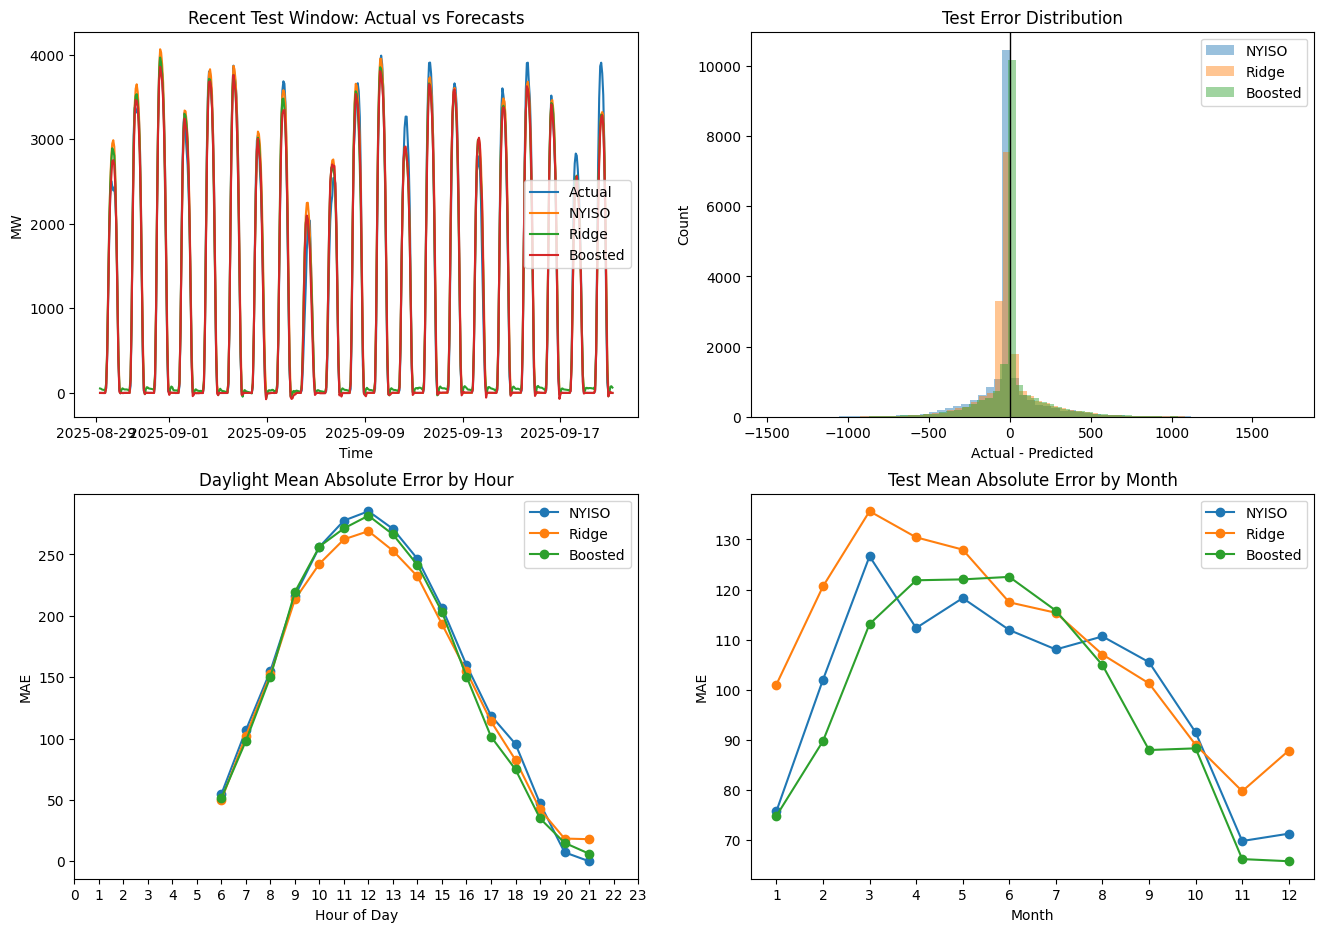

In [82]:
diag = pd.DataFrame({
    "time_stamp": df_system.loc[test_model_mask, "time_stamp"].values,
    "time_local": df_system.loc[test_model_mask, "time_local"].values,
    "actual_mw": baseline_actual_test.values,
    "baseline_pred": baseline_forecast_test.values,
    "ridge_pred": ridge_corrected.values,
    "tree_pred": tree_corrected.values,
    "hour_local": df_system.loc[test_model_mask, "hour_local"].values,
    "month_local": df_system.loc[test_model_mask, "month_local"].values,
    "is_daylight_proxy": df_system.loc[test_model_mask, "is_daylight_proxy"].values,
})

diag["baseline_error"] = diag["actual_mw"] - diag["baseline_pred"]
diag["ridge_error"] = diag["actual_mw"] - diag["ridge_pred"]
diag["tree_error"] = diag["actual_mw"] - diag["tree_pred"]

diag["baseline_abs_error"] = diag["baseline_error"].abs()
diag["ridge_abs_error"] = diag["ridge_error"].abs()
diag["tree_abs_error"] = diag["tree_error"].abs()

diag_day = diag.loc[diag["is_daylight_proxy"] == 1].copy()

recent_plot = diag.tail(min(24 * 21, len(diag))).copy()

hourly_day = (
    diag_day.groupby("hour_local", as_index=False)[
        ["baseline_abs_error", "ridge_abs_error", "tree_abs_error"]
    ].mean()
)

monthly_all = (
    diag.groupby("month_local", as_index=False)[
        ["baseline_abs_error", "ridge_abs_error", "tree_abs_error"]
    ].mean()
)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

axes[0, 0].plot(recent_plot["time_local"], recent_plot["actual_mw"], label="Actual")
axes[0, 0].plot(recent_plot["time_local"], recent_plot["baseline_pred"], label="NYISO")
axes[0, 0].plot(recent_plot["time_local"], recent_plot["ridge_pred"], label="Ridge")
axes[0, 0].plot(recent_plot["time_local"], recent_plot["tree_pred"], label="Boosted")
axes[0, 0].set_title("Recent Test Window: Actual vs Forecasts")
axes[0, 0].set_xlabel("Time")
axes[0, 0].set_ylabel("MW")
axes[0, 0].legend()

axes[0, 1].hist(diag["baseline_error"], bins=60, alpha=0.45, label="NYISO")
axes[0, 1].hist(diag["ridge_error"], bins=60, alpha=0.45, label="Ridge")
axes[0, 1].hist(diag["tree_error"], bins=60, alpha=0.45, label="Boosted")
axes[0, 1].axvline(0, color="black", linewidth=1)
axes[0, 1].set_title("Test Error Distribution")
axes[0, 1].set_xlabel("Actual - Predicted")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend()

axes[1, 0].plot(hourly_day["hour_local"], hourly_day["baseline_abs_error"], marker="o", label="NYISO")
axes[1, 0].plot(hourly_day["hour_local"], hourly_day["ridge_abs_error"], marker="o", label="Ridge")
axes[1, 0].plot(hourly_day["hour_local"], hourly_day["tree_abs_error"], marker="o", label="Boosted")
axes[1, 0].set_title("Daylight Mean Absolute Error by Hour")
axes[1, 0].set_xlabel("Hour of Day")
axes[1, 0].set_ylabel("MAE")
axes[1, 0].set_xticks(range(24))
axes[1, 0].legend()

axes[1, 1].plot(monthly_all["month_local"], monthly_all["baseline_abs_error"], marker="o", label="NYISO")
axes[1, 1].plot(monthly_all["month_local"], monthly_all["ridge_abs_error"], marker="o", label="Ridge")
axes[1, 1].plot(monthly_all["month_local"], monthly_all["tree_abs_error"], marker="o", label="Boosted")
axes[1, 1].set_title("Test Mean Absolute Error by Month")
axes[1, 1].set_xlabel("Month")
axes[1, 1].set_ylabel("MAE")
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].legend()

plt.show()